# Proyecto de Ciencia de Datos 2026 - Avance 2: Análisis Exploratorio de Datos (EDA)
**Universidad Técnica Federico Santa María**
**Equipo:** Javier Andrade, Lucas Martínez, Benjamín Ramos

---

## 2. Continuidad con el Avance 1

Antes de sumergirnos en los datos, recordamos brevemente el contexto de nuestro proyecto para entender el propósito de este análisis exploratorio:

* **La problemática estudiada:** El uso intensivo de pantallas convive con problemas de sueño y estrés en jóvenes adultos. Sin embargo, diferenciar un uso alto de un uso problemático (adicción) suele hacerse de forma subjetiva.
* **La pregunta principal:** ¿Es posible identificar si una persona de 18 a 35 años presenta un patrón de uso problemático de pantallas ($Y$), a partir de sus hábitos digitales, de sueño y contexto personal en una semana típica ($X$), usando solo la información al momento de la evaluación ($T$)?
* **El objetivo del análisis:** Explorar progresivamente los datos de hábitos digitales para obtener evidencia empírica que nos permita comprender mejor el problema, evaluar la calidad de los datos y detectar patrones útiles para el futuro modelado.
* **La variable objetivo ($Y$):** `addicted_label` (Indicador binario: 1 = presenta uso problemático, 0 = no lo presenta).
* **Principales variables predictoras ($X$):** Tiempo de pantalla (diario y fin de semana), horas en redes sociales, gaming y trabajo/estudio, horas de sueño, notificaciones, aperturas de apps, edad, género, nivel de estrés e impacto académico/laboral.
* **El contexto temporal o contextual ($T$):** Una semana típica de uso (evaluación transversal, estado actual de la persona).
* **El dataset utilizado:** Dataset público de Kaggle sobre hábitos de uso de pantalla, compuesto por el archivo`adiccion_pantalla.csv`.

In [9]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Carga de los datos (Solo conjunto de entrenamiento)
df = pd.read_csv('../data/raw/adiccion_pantalla.csv')

print("Datos de entrenamiento cargados exitosamente.")
display(df)

Datos de entrenamiento cargados exitosamente.


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


---
## 3.1. Estructura y calidad de los datos

En esta sección realizaremos una revisión básica del dataset para identificar su forma, tipos de variables, presencia de valores nulos, registros duplicados e inconsistencias lógicas.

In [2]:
# 1. Número de observaciones y variables
num_obs, num_vars = df.shape
print(f"Número de observaciones (filas): {num_obs}")
print(f"Número de variables (columnas): {num_vars}\n")

# 2. Tipos de variables
print("Tipos de variables en el dataset:")
print(df.dtypes)

Número de observaciones (filas): 691369
Número de variables (columnas): 14

Tipos de variables en el dataset:
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object


In [3]:
# 3. Valores faltantes (Nulos)
print("Cantidad de valores faltantes por variable:")
missing_values = df.isnull().sum()
missing_percentages = (missing_values / num_obs) * 100

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_values, 
    'Porcentaje (%)': missing_percentages
}).sort_values(by='Porcentaje (%)', ascending=False)

display(missing_df)

Cantidad de valores faltantes por variable:


,Valores Faltantes,Porcentaje (%)
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [4]:
# 4. Registros duplicados
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados en el dataset: {duplicados}")

Cantidad de registros duplicados en el dataset: 0


In [5]:
# 5. Valores fuera de rango y posibles valores atípicos (Variables Numéricas)
print("Resumen estadístico de las variables numéricas:")
display(df.describe().T)

# Nota: Revisaremos que 'age' esté entre 18 y 35, y que las horas tengan sentido.

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [6]:
# 6. Categorías inconsistentes (Variables Categóricas)
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']

print("Revisión de categorías únicas para detectar inconsistencias:")
for col in categorical_cols:
    print(f"\nVariable: {col}")
    print(df[col].value_counts(dropna=False))

Revisión de categorías únicas para detectar inconsistencias:

Variable: gender
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

Variable: stress_level
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

Variable: academic_work_impact
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


### 5. Valores fuera de rango usando visualizaciones (Outliers)

Aunque la tabla estadística `describe()` nos mostró que los valores mínimos y máximos tienen sentido lógico (ej. edad entre 18 y 35), es importante utilizar gráficos para ver cómo se distribuyen los datos y si existen concentraciones inusuales o *outliers* estadísticos.

Para esto utilizaremos:
1. **Gráficos de Caja (Boxplots):** Nos permiten visualizar rápidamente la mediana, los cuartiles y detectar cualquier valor que se escape de los límites normales (bigotes).
2. **Histogramas:** Nos ayudan a ver la forma de la distribución (si es simétrica, si está sesgada, etc.).

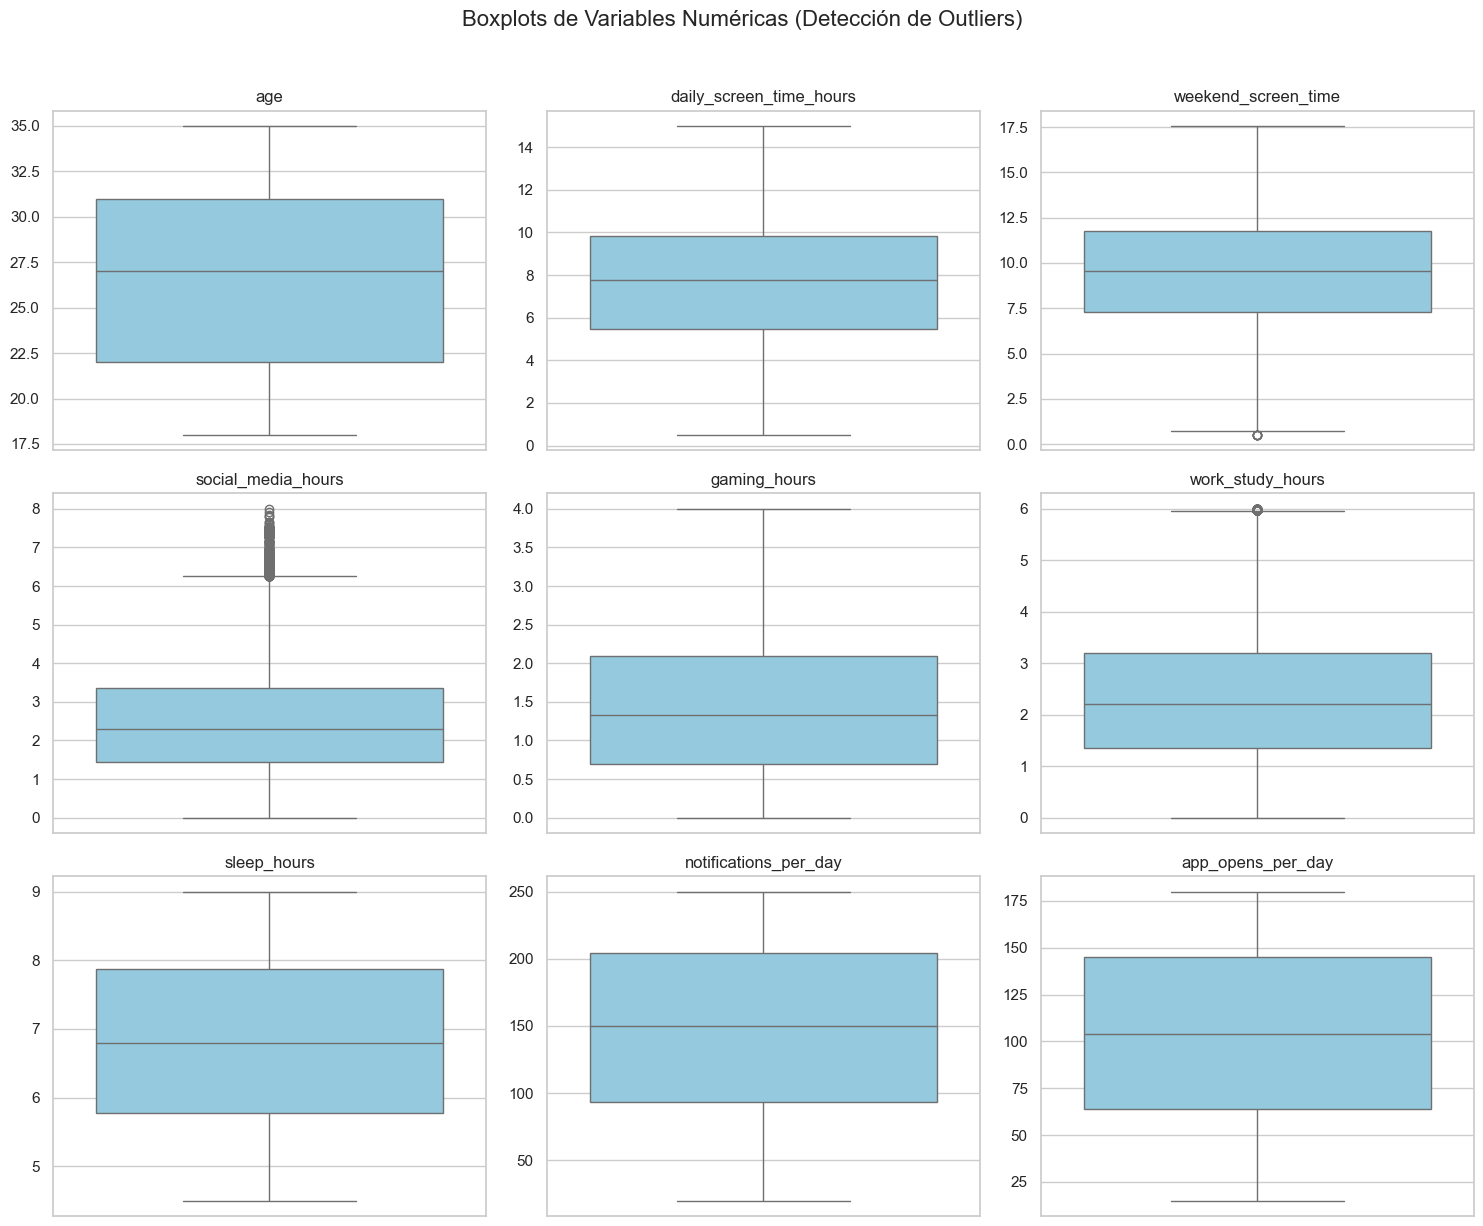

In [7]:
# Seleccionamos las columnas numéricas que queremos analizar
num_cols = [
    'age', 'daily_screen_time_hours', 'weekend_screen_time', 
    'social_media_hours', 'gaming_hours', 'work_study_hours', 
    'sleep_hours', 'notifications_per_day', 'app_opens_per_day'
]

# Creamos una figura con subgráficos para los Boxplots
plt.figure(figsize=(15, 12))
plt.suptitle('Boxplots de Variables Numéricas (Detección de Outliers)', fontsize=16, y=1.02)

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Matriz de 3x3 gráficos
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.ylabel('') # Ocultamos el nombre del eje Y para que quede más limpio

plt.tight_layout()
plt.show()

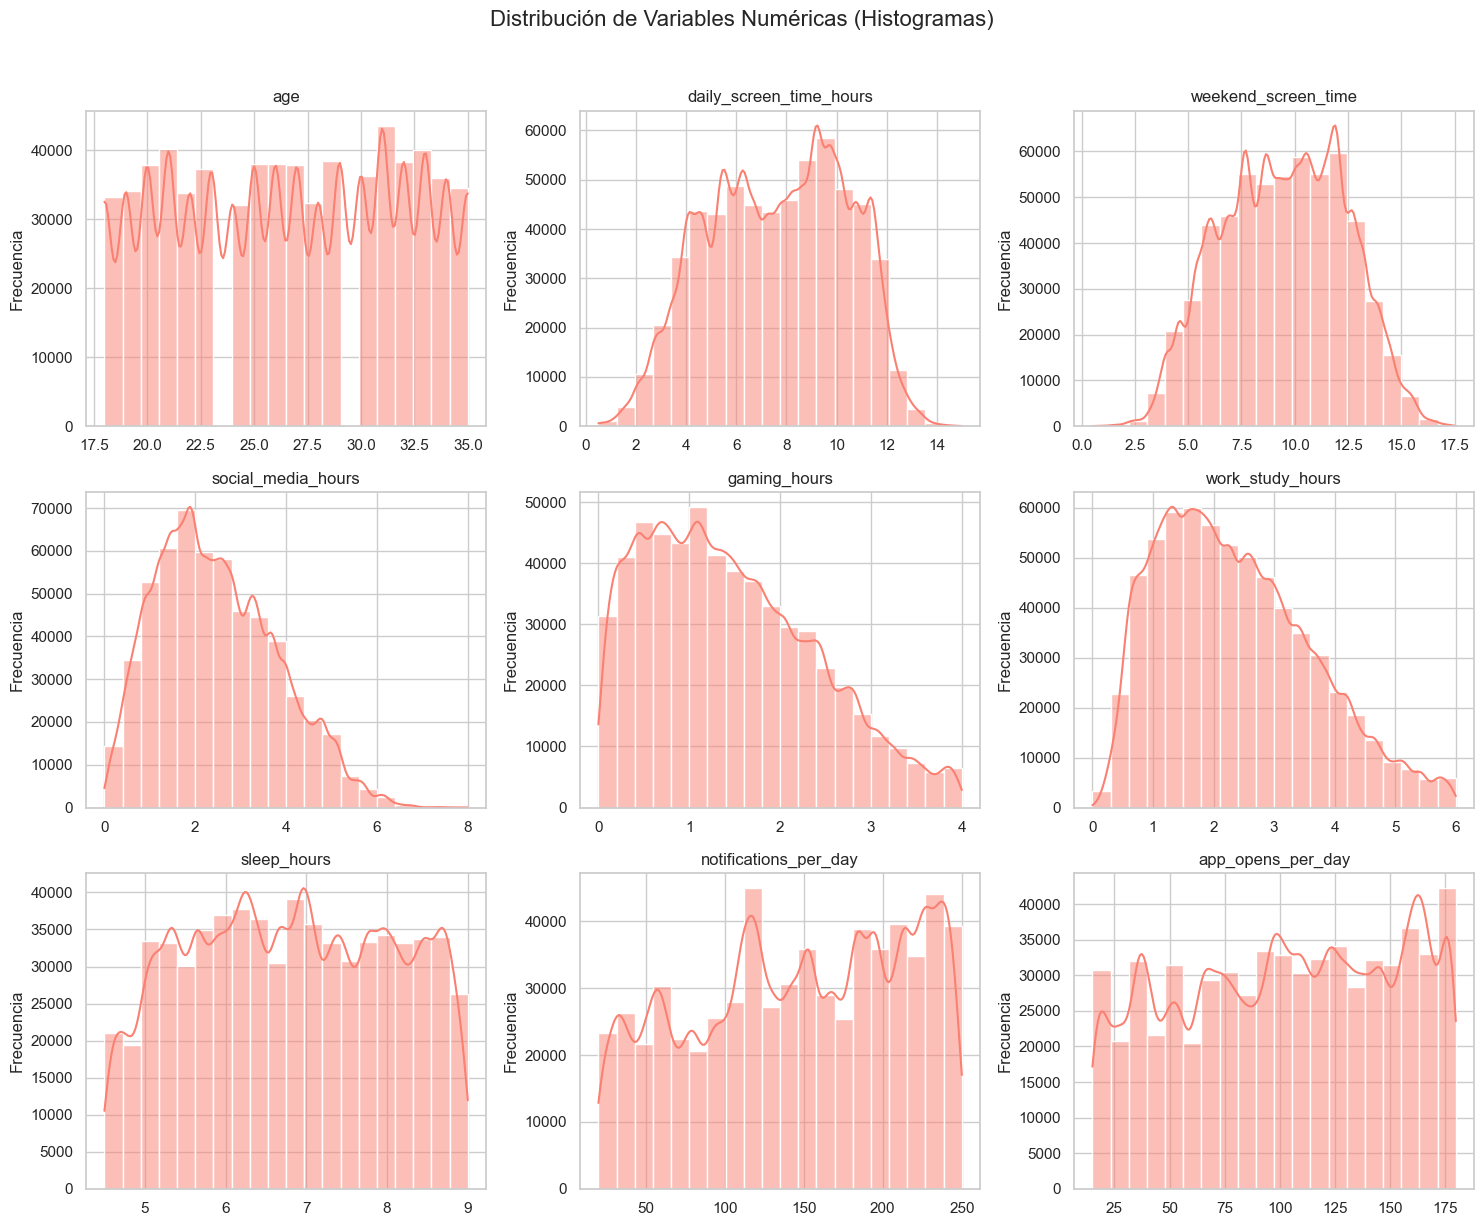

In [8]:
# Creamos una figura con subgráficos para los Histogramas
plt.figure(figsize=(15, 12))
plt.suptitle('Distribución de Variables Numéricas (Histogramas)', fontsize=16, y=1.02)

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=20, kde=True, color='salmon')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**¿Qué problemas encontramos y qué decisiones tomamos?**

1. **Valores Faltantes:** Confirmamos que nuestra variable objetivo `addicted_label` está completa en el set de entrenamiento (0 nulos), lo cual es ideal. Sin embargo, las variables predictoras presentan entre un 4% y un 19% de datos faltantes. 
   * *Decisión:* No eliminaremos las filas con nulos (DropNA) para no perder volumen de datos. En la etapa de modelado aplicaremos un pipeline de imputación (mediana para numéricas y moda para categóricas).
2. **Distribución y Valores Atípicos (Outliers):** Tanto la estadística descriptiva como los Boxplots demuestran que **no existen valores atípicos severos** ni errores lógicos. 
   * La edad está acotada entre 18 y 35 años exactos.
   * Los tiempos máximos de uso diario (15 hrs) y horas de sueño (4.5 a 9 hrs) están dentro de límites reales, y no hay puntos que se escapen de los bigotes en los gráficos.
   * *Decisión:* Al ser datos con distribución uniforme y sin valores extremos irreales, no será necesario aplicar técnicas de recorte ni eliminar outliers antes de modelar.
3. **Categorías y Duplicados:** Las variables categóricas (`gender`, `stress_level`, `academic_work_impact`) están completamente limpias, sin categorías solapadas. Además, el dataset tiene 0 registros duplicados.
4. **Cobertura Temporal/Contextual ($T$):** La ausencia de fechas confirma que los datos representan los hábitos estabilizados de una semana típica de cada usuario.